In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = fetch_california_housing()

In [3]:
print(fetch_california_housing().DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
#1

In [5]:
df = pd.DataFrame(data.data, columns=data.feature_names)

In [6]:
df['MedHouseVal'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
#2

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [9]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [10]:
#3

In [11]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X_train.shape

(16512, 8)

In [14]:
X_test.shape

(4128, 8)

In [15]:
#4

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [18]:
# Metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Model metrics features")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test  RMSE: {rmse_test:.4f}")
print(f"Train R2:   {r2_train:.4f}")
print(f"Test  R2:   {r2_test:.4f}")

Model metrics features
Train RMSE: 0.7197
Test  RMSE: 0.7456
Train R2:   0.6126
Test  R2:   0.5758


In [19]:
#5

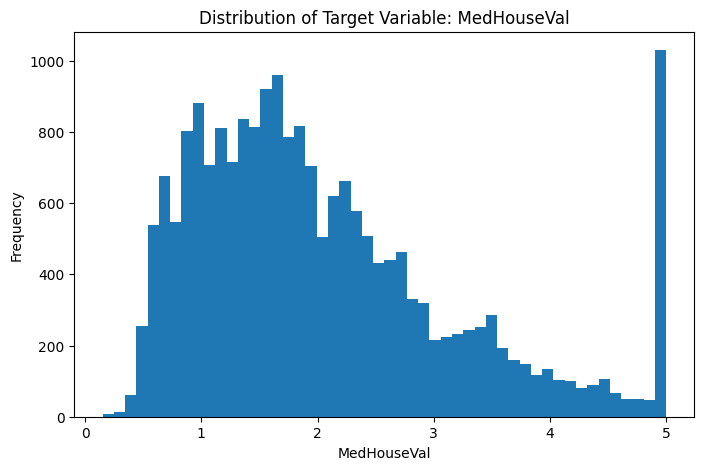

In [20]:
# Plotting the distribution graph of the target variable
plt.figure(figsize=(8, 5))
plt.hist(df['MedHouseVal'], bins=50)
plt.xlabel("MedHouseVal")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable: MedHouseVal")
plt.show()

In [21]:
# Conclusion:
# The distribution of MedHouseVal is right-skewed, with most values between 1 and 3. 
# There are some higher values forming a long tail, which indicates the presence of outliers.

In [22]:
#6

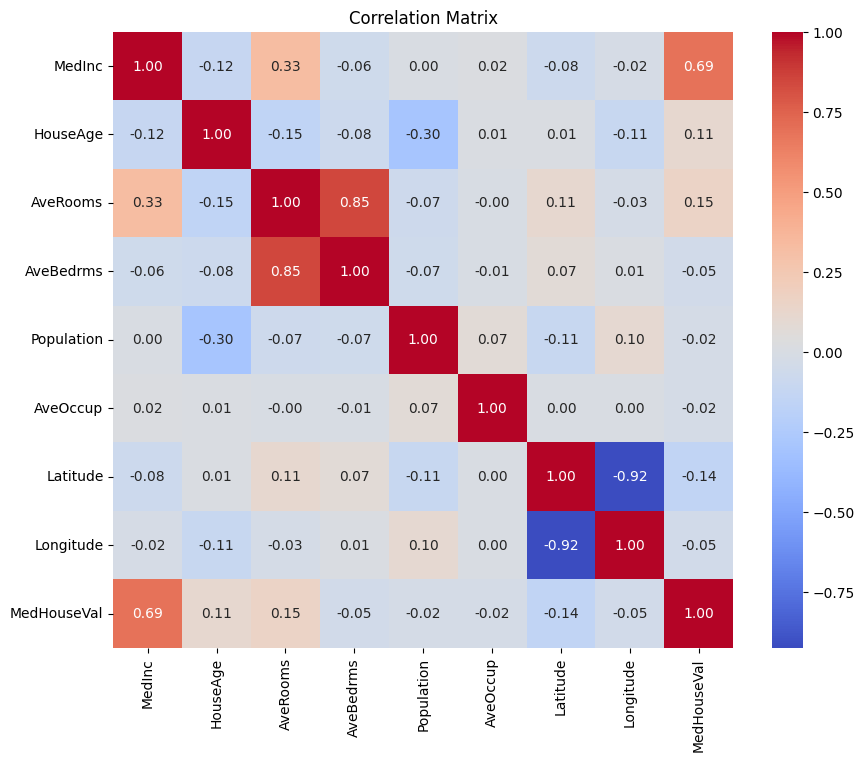

In [23]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [24]:
df_reduced = df.drop(columns=['Population', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude'])

In [25]:
df_reduced.head()

,MedInc,HouseAge,AveRooms,MedHouseVal
0,8.3252,41.0,6.984127,4.526
1,8.3014,21.0,6.238137,3.585
2,7.2574,52.0,8.288136,3.521
3,5.6431,52.0,5.817352,3.413
4,3.8462,52.0,6.281853,3.422


In [26]:
X = df_reduced.drop(columns=['MedHouseVal'])
y = df_reduced['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Model metrics after removing features")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test  RMSE: {rmse_test:.4f}")
print(f"Train R2:   {r2_train:.4f}")
print(f"Test  R2:   {r2_test:.4f}")

Model metrics after removing features
Train RMSE: 0.8046
Test  RMSE: 0.8117
Train R2:   0.5157
Test  R2:   0.4972


In [27]:
#7

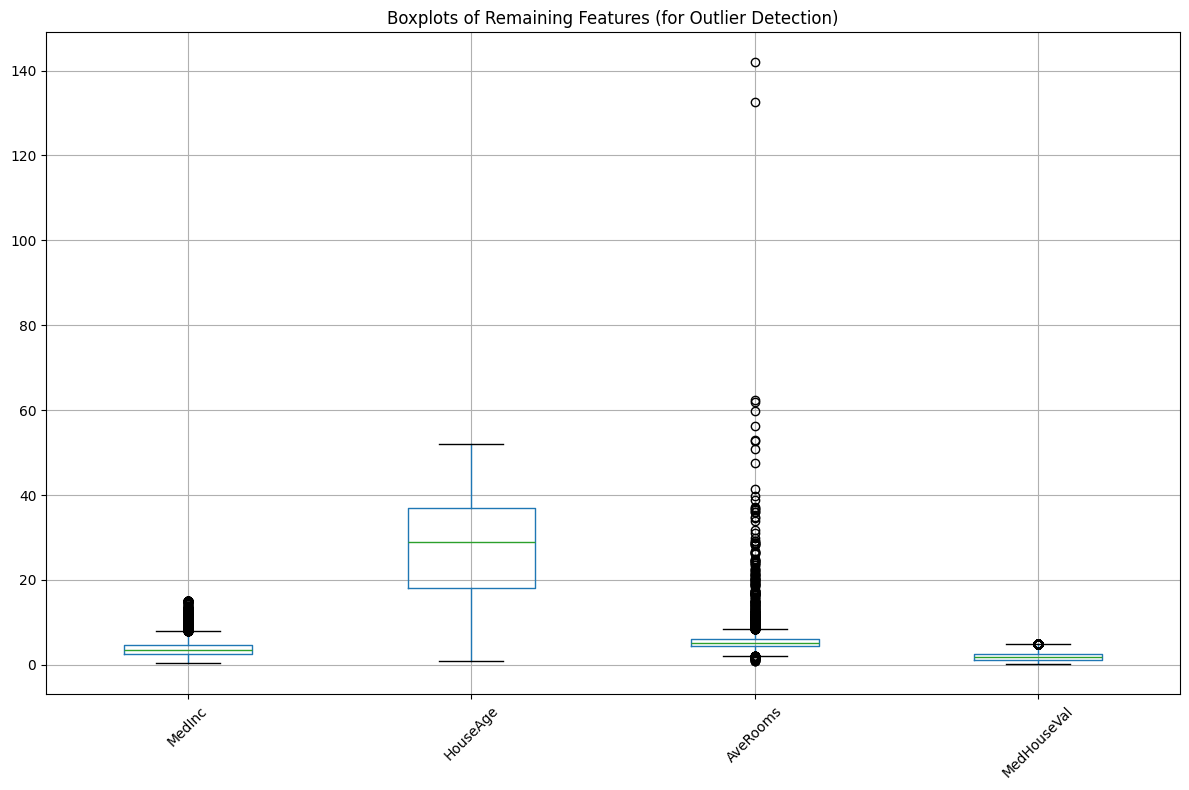

In [28]:
#Boxplot before removing outliers
plt.figure(figsize=(12, 8))
df_reduced.boxplot(rot=45)
plt.title("Boxplots of Remaining Features (for Outlier Detection)")
plt.tight_layout()
plt.show()

In [29]:
df_clean = df_reduced.copy()

for col in df_clean.columns:
    if col == 'MedHouseVal':
        continue

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print("Shape after outlier removal:", df_clean.shape)

Shape after outlier removal: (19520, 4)


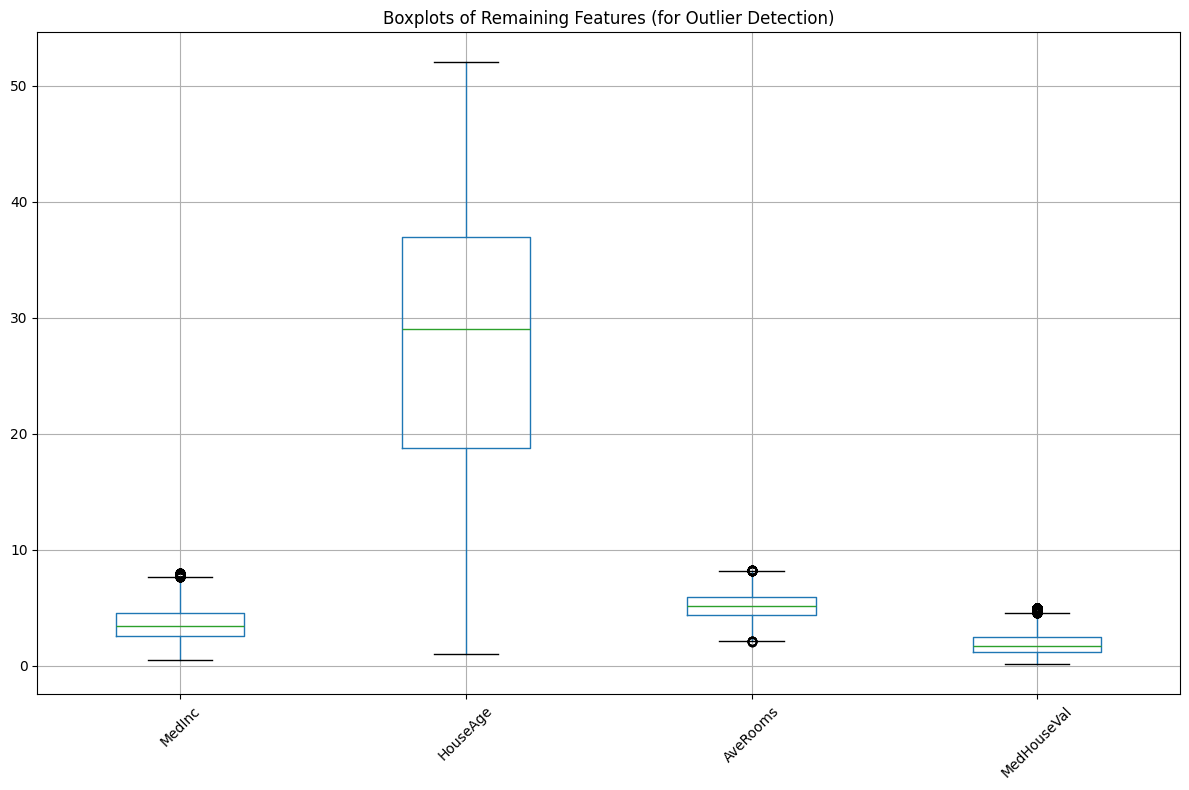

In [30]:
#Boxplot after removing outliers
plt.figure(figsize=(12, 8))
df_clean.boxplot(rot=45)
plt.title("Boxplots of Remaining Features (for Outlier Detection)")
plt.tight_layout()
plt.show()

In [32]:
X = df_clean.drop(columns=['MedHouseVal'])
y = df_clean['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Metrics after removing features and outliers")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test  RMSE: {rmse_test:.4f}")
print(f"Train R2:   {r2_train:.4f}")
print(f"Test  R2:   {r2_test:.4f}")

Metrics after removing features and outliers
Train RMSE: 0.7691
Test  RMSE: 0.7672
Train R2:   0.4739
Test  R2:   0.4816


In [ ]:
#8

In [34]:
df_transformed = df_clean.copy()

df_transformed["MedInc_log"] = np.log1p(df_transformed["MedInc"])
df_transformed["AveRooms_sqrt"] = np.sqrt(df_transformed["AveRooms"])
df_transformed["HouseAge_sq"] = df_transformed["HouseAge"] ** 2

df_transformed = df_transformed.drop(columns=["MedInc", "AveRooms", "HouseAge"])

df_transformed.head()

,MedHouseVal,MedInc_log,AveRooms_sqrt,HouseAge_sq
3,3.413,1.893579,2.411919,2704.0
4,3.422,1.578195,2.506363,2704.0
5,2.697,1.616771,2.182122,2704.0
6,2.992,1.538822,2.220790,2704.0
7,2.414,1.415853,2.190326,2704.0


In [35]:
X = df_transformed.drop(columns=["MedHouseVal"])
y = df_transformed["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Metrics after mathematical feature transformations")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test  RMSE: {rmse_test:.4f}")
print(f"Train R2:   {r2_train:.4f}")
print(f"Test  R2:   {r2_test:.4f}")

Metrics after mathematical feature transformations
Train RMSE: 0.7919
Test  RMSE: 0.7927
Train R2:   0.4423
Test  R2:   0.4466


In [ ]:
#9

In [ ]:
#a.

In [ ]:
# The following transformations were performed:
# Initial data validation
# —the data was loaded, no missing data was detected.
# Removal of features with low information value
# Based on correlation analysis, the following were removed:
# Population, AveOccup, Latitude, Longitude, AveBedrms — as they had a low or negative correlation with the target variable.
# Outlier removal
# The remaining features were cleaned using the IQR method.
# This eliminated extreme values that could impair training.
# Mathematical transformations of features
# Several transformations were performed:
# MedInc_log — logarithm of income
# AveRooms_sqrt — root of the mean number of rooms
# HouseAge_sq — squared age of houses

In [ ]:
#b.

In [37]:
results = [
    {
        "Model": "Baseline",
        "RMSE (Train)": 0.7197,
        "RMSE (Test)": 0.7456,
        "R2 (Train)": 0.6126,
        "R2 (Test)": 0.5758,
        "Features Used": "All original features"
    },
    {
        "Model": "Correlation-based Feature Removal",
        "RMSE (Train)": 0.8046,
        "RMSE (Test)": 0.8117,
        "R2 (Train)": 0.5157,
        "R2 (Test)": 0.4972,
        "Features Used": "Only features with high correlation"
    },
    {
        "Model": "Outlier Removal",
        "RMSE (Train)": 0.7691,
        "RMSE (Test)": 0.7672,
        "R2 (Train)": 0.4739,
        "R2 (Test)": 0.4816,
        "Features Used": "Selected features after outlier removal"
    },
    {
        "Model": "Mathematical Transformations",
        "RMSE (Train)": 0.7919,
        "RMSE (Test)": 0.7927,
        "R2 (Train)": 0.4423,
        "R2 (Test)": 0.4466,
        "Features Used": "Log, square root, square transformations"
    }
]

df_models = pd.DataFrame(results)
df_models

,Model,RMSE (Train),RMSE (Test),R2 (Train),R2 (Test),Features Used
0,Baseline,0.7197,0.7456,0.6126,0.5758,All original features
1,Correlation-based Feature Removal,0.8046,0.8117,0.5157,0.4972,Only features with high correlation
2,Outlier Removal,0.7691,0.7672,0.4739,0.4816,Selected features after outlier removal
3,Mathematical Transformations,0.7919,0.7927,0.4423,0.4466,"Log, square root, square transformations"


In [ ]:
#c.

In [ ]:
# The baseline model with the original features performs the best.

# Feature manipulations (removing correlated features, removing outliers, applying transformations) 
#decreased the model's performance.

#It may be worth considering more complex models or regularization instead of removing features/outliers 
#to improve predictive performance.